# Imports

In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

# Format data (Wt, 24h)

In [2]:
df_org = pd.read_excel("../data/unformated/Daten_Label_24hWt.xlsx", sheet_name="formatted")
rows_unl = [i for i in range(len(df_org)) if i % 2 == 0]
rows_l = [i for i in range(len(df_org)) if i % 2 != 0]
df = df_org.drop(rows_l, axis=0)
df_l = df_org.drop(rows_unl, axis=0)

In [3]:
# add labeled values as new columns
cols = df_org.columns[1:]
for col in cols:
    df[f"{col}_l"] = df_l[col].values

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l,exp2_37deg_4_l,exp4_22deg_1_l,exp4_22deg_2_l,exp4_22deg_3_l,exp4_22deg_4_l,exp4_37deg_1_l,exp4_37deg_2_l,exp4_37deg_3_l,exp4_37deg_4_l
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.297905,1.413610,2.152663,2.088974,1.241209,1.523959,10.029840,15.876957,14.942153,10.288102
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,4.607286,4.431282,3.054066,3.394669,2.110951,2.512315,31.621042,33.167724,26.167475,24.345149
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.312451,0.359753,4.698023,4.268724,2.673547,3.430581,7.514651,9.460271,11.039339,6.770959
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.556659,0.517282,4.570194,4.422733,3.048503,2.931791,9.367357,9.167949,8.102832,7.341369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000000,0.000000,1.440343,1.202063,0.000000,0.042314,0.000000,0.685638,1.190872,0.000000
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.003247,0.000000,0.000000,0.000000,0.000000,0.020399,0.023651,0.000000,0.000000,0.000000
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Preprocessing
## Relative values

In [4]:
cols = df.columns[1:]

for col in cols:
    exp = col.split("_")[0]
    exp_cols = [col for col in cols if "rel" not in col and exp in col]
    sum_exp = df[exp_cols].to_numpy().sum()
    abs_values = df[col].values
    rel_values = [val/sum_exp for val in abs_values]

    df[f"{col}_rel"] = rel_values

    # print("Experiment:", exp)
    # print("Experiment columns:", exp_cols)
    # print("Sum experiment:", sum_exp)
    # print("Column:", col)
    # print("Absolute values:", abs_values)
    # print("Relative values:", rel_values)
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l_rel,exp2_37deg_4_l_rel,exp4_22deg_1_l_rel,exp4_22deg_2_l_rel,exp4_22deg_3_l_rel,exp4_22deg_4_l_rel,exp4_37deg_1_l_rel,exp4_37deg_2_l_rel,exp4_37deg_3_l_rel,exp4_37deg_4_l_rel
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.001162,0.001266,0.000246,0.000238,0.000142,0.000174,0.001145,0.001812,0.001705,0.001174
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.004126,0.003969,0.000349,0.000387,0.000241,0.000287,0.003608,0.003785,0.002986,0.002778
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.000280,0.000322,0.000536,0.000487,0.000305,0.000391,0.000858,0.001080,0.001260,0.000773
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.000499,0.000463,0.000522,0.000505,0.000348,0.000335,0.001069,0.001046,0.000925,0.000838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000000,0.000000,0.000164,0.000137,0.000000,0.000005,0.000000,0.000078,0.000136,0.000000
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.000003,0.000000,0.000000,0.000000,0.000000,0.000002,0.000003,0.000000,0.000000,0.000000
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [5]:
df.filter(regex="exp2").filter(regex="rel").to_numpy().sum()

np.float64(0.9999999999999999)

In [6]:
df.filter(regex="exp4").filter(regex="rel").to_numpy().sum()

np.float64(1.0)

## Means

In [10]:
df["mean_22deg"] = df.filter(regex=r".*_22deg_\d+_rel").mean(axis=1)
df["mean_37deg"] = df.filter(regex=r".*_37deg_\d+_rel").mean(axis=1)
df["mean_22deg_l"] = df.filter(regex=r".*_22deg_\d+_l_rel").mean(axis=1)
df["mean_37deg_l"] = df.filter(regex=r".*_37deg_\d+_l_rel").mean(axis=1)
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp4_22deg_3_l_rel,exp4_22deg_4_l_rel,exp4_37deg_1_l_rel,exp4_37deg_2_l_rel,exp4_37deg_3_l_rel,exp4_37deg_4_l_rel,mean_22deg,mean_37deg,mean_22deg_l,mean_37deg_l
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.000142,0.000174,0.001145,0.001812,0.001705,0.001174,0.000453,0.000528,3.641691e-04,0.001325
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000016,0.000072,0.000000e+00,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.000241,0.000287,0.003608,0.003785,0.002986,0.002778,0.000816,0.002037,5.025434e-04,0.003410
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.000305,0.000391,0.000858,0.001080,0.001260,0.000773,0.001294,0.000484,5.577523e-04,0.000636
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.000348,0.000335,0.001069,0.001046,0.000925,0.000838,0.000831,0.000708,4.997085e-04,0.000690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000000,0.000005,0.000000,0.000078,0.000136,0.000000,0.007256,0.006694,3.829635e-05,0.000027
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.000000,0.000002,0.000003,0.000000,0.000000,0.000000,0.000232,0.000210,3.778138e-07,0.000001
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000


## Degree of labeling

In [11]:
df["sum_22deg"] = df[["mean_22deg", "mean_22deg_l"]].sum(axis=1)
df["sum_37deg"] = df[["mean_37deg", "mean_37deg_l"]].sum(axis=1)
df["dol_22deg"] = df["mean_22deg_l"] /  df["sum_22deg"]
df["dol_37deg"] = df["mean_37deg_l"] /  df["sum_37deg"]
df.to_csv("../data/formated/wt_24h.csv", index=False)
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp4_37deg_3_l_rel,exp4_37deg_4_l_rel,mean_22deg,mean_37deg,mean_22deg_l,mean_37deg_l,sum_22deg,sum_37deg,dol_22deg,dol_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.001705,0.001174,0.000453,0.000528,3.641691e-04,0.001325,0.000817,0.001854,0.445809,0.715017
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000000,0.000000,0.000016,0.000072,0.000000e+00,0.000000,0.000016,0.000072,0.000000,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.002986,0.002778,0.000816,0.002037,5.025434e-04,0.003410,0.001319,0.005447,0.381068,0.626062
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.001260,0.000773,0.001294,0.000484,5.577523e-04,0.000636,0.001852,0.001119,0.301230,0.567911
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.000925,0.000838,0.000831,0.000708,4.997085e-04,0.000690,0.001330,0.001398,0.375643,0.493562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,NaN,NaN
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000136,0.000000,0.007256,0.006694,3.829635e-05,0.000027,0.007294,0.006721,0.005250,0.003983
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.000000,0.000000,0.000232,0.000210,3.778138e-07,0.000001,0.000232,0.000211,0.001626,0.004795
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,NaN,NaN


Text(0.5, 0.98, 'Distribution of labeling degree')

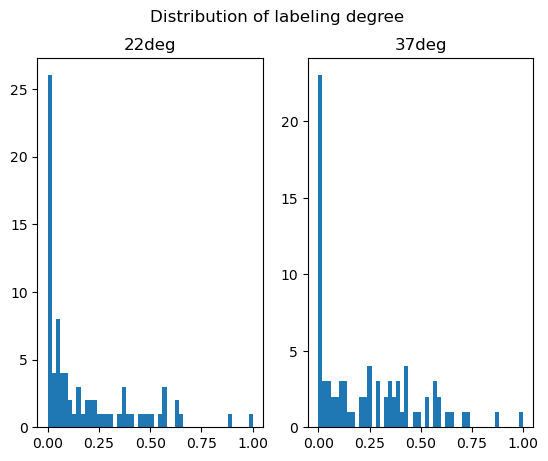

In [12]:
fig, axs = plt.subplots(1, 2)

for i, title in zip([0, 1], ["dol_22deg", "dol_37deg"]):
    axs[i].hist(df[title].values, bins=50)
    axs[i].set_title(f"{title.split("_")[1]}")

plt.suptitle("Distribution of labeling degree")

# Normalisation